In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'microsoft_stock')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints''time_series', 'real', 'microsoft_stock')
OUT_PATH = os.path.join(CURRENT_DIR, 'out' 'time_series', 'real', 'microsoft_stock')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [32]:
df_data = pd.read_csv(os.path.join(DATA_PATH, 'Microsoft_Stock.csv'))
df_data.shape

(1511, 6)

In [33]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1511.0,1.073860e+02,5.669133e+01,40.34,5.786000e+01,93.99,1.394400e+02,2.450300e+02
High,1511.0,1.084375e+02,5.738228e+01,40.74,5.806000e+01,95.10,1.403250e+02,2.461300e+02
Low,1511.0,1.062945e+02,5.597716e+01,39.72,5.742000e+01,92.92,1.378250e+02,2.429200e+02
Close,1511.0,1.074221e+02,5.670230e+01,40.29,5.785500e+01,93.86,1.389650e+02,2.449900e+02
Volume,1511.0,3.019863e+07,1.425266e+07,101612.00,2.136213e+07,26629615.00,3.431962e+07,1.352271e+08


In [34]:
df_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [35]:
df_data['Date'] = pd.to_datetime(df_data['Date'])

In [36]:
df_data.nunique()

Date      1511
Open      1409
High      1400
Low       1397
Close     1398
Volume    1511
dtype: int64

In [37]:
df_data.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [38]:
df_data.duplicated().sum()

0

In [39]:
df_data.set_index('Date', inplace=True)

In [40]:
df_data.sort_index(inplace=True)

In [42]:
date_diffs = df_data.index.diff().dropna()
date_diffs.value_counts()

Date
1 days 00:00:00    1179
3 days 00:00:00     267
4 days 00:00:00      40
2 days 00:00:00       6
1 days 21:00:00       4
3 days 03:00:00       4
0 days 21:00:00       4
2 days 03:00:00       4
2 days 21:00:00       1
4 days 03:00:00       1
Name: count, dtype: int64

In [43]:
# Redondear las fechas a la hora más cercana
df_data.index = df_data.index.round('D')

# Rellenar los huecos necesarios
df_data = df_data.asfreq('D')

# Mostrar el resultado
df_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-04-02,40.60,40.76,40.31,40.72,36865322.0
2015-04-03,40.66,40.74,40.12,40.29,37487476.0
2015-04-04,NaN,NaN,NaN,NaN,NaN
2015-04-05,NaN,NaN,NaN,NaN,NaN
2015-04-06,NaN,NaN,NaN,NaN,NaN


In [44]:
date_diffs = df_data.index.diff().dropna()
date_diffs.value_counts()

Date
1 days    2191
Name: count, dtype: int64

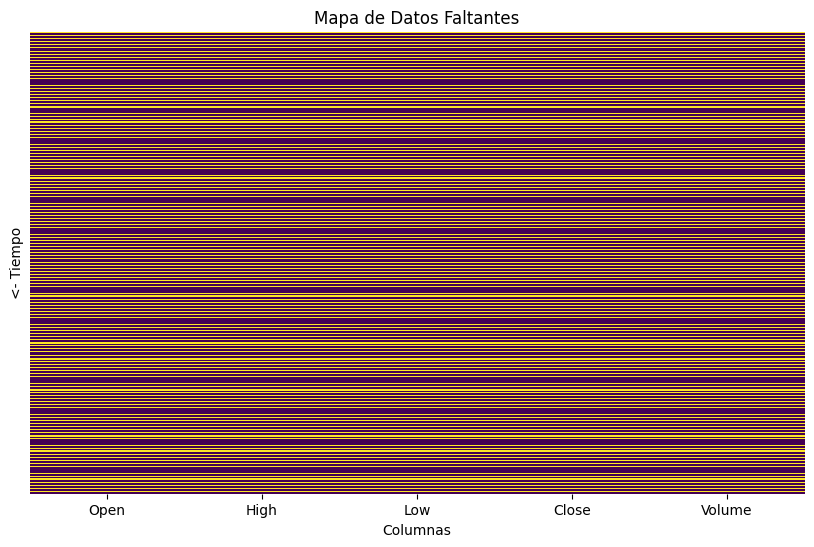

In [47]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Mapa de calor para mostrar los datos faltantes
sns.heatmap(df_data.isnull(), cbar=False, cmap="viridis", yticklabels=False)

# Etiquetas y título
plt.title("Mapa de Datos Faltantes")
plt.xlabel("Columnas")
plt.ylabel("<- Tiempo")
plt.show()

In [52]:
df_data = df_data.interpolate(method='time')
df_data.dropna(inplace=True)
df_data.shape

(2192, 5)

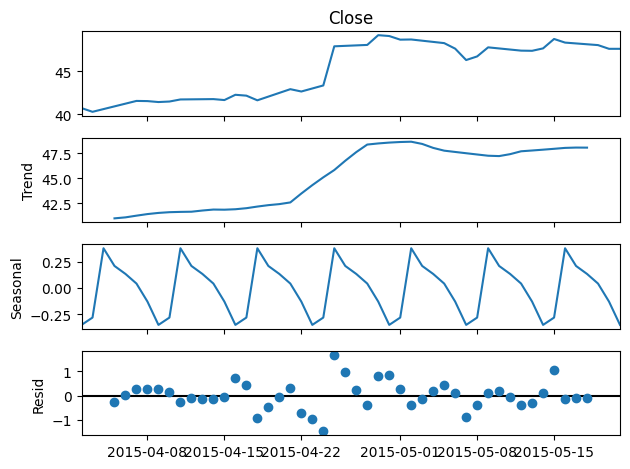

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(df_data['Close'][:50], model="additive")
decomposition.plot()
plt.show()

In [59]:
unique_values = {}
for col in df_data.columns:
    unique_values[col] = np.unique(df_data[col])

In [61]:
unique_values_df = pd.DataFrame(
    data={
        'variables': df_data.columns,
        'N. unique values': [len(unique_values[key]) for key in unique_values.keys()],
        '% unique values': [(len(unique_values[key])/df_data.shape[0])*100 for key in unique_values.keys()],
        # 'Unique values': [unique_values[key] for key in unique_values.keys()]
    }
)
unique_values_df

,variables,N. unique values,% unique values
0,Open,2064,94.160584
1,High,2052,93.613139
2,Low,2049,93.476277
3,Close,2037,92.928832
4,Volume,2192,100.000000


In [62]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)

In [4]:
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)
df_data.rename(columns={"Close": "y"}, inplace=True)
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)